In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
import numpy as np
from scipy.stats import poisson
import seaborn as sns
from collections import Counter
import matplotlib.patches as mpatches
import random

In [23]:
# Load data
df = pd.read_csv('Michelin_cleaned up.csv')

# Remove rows where the Cuisine column is missing
df = df.dropna(subset=['Cuisine'])

# Split the cuisine string into a list of cuisines
# also remove extra spaces around each cuisine name
df['Cuisine_list'] = df['Cuisine'].apply(lambda x: [c.strip() for c in x.split(',')])

In [24]:
# Build network
G = nx.Graph()

# Add each restaurant as a node in the graph
for _, row in df.iterrows():
    G.add_node(row['Name'])

# Create a disctionary where:
# key = cuisine type
# value = list of restaurants with that cuisine
cuisine_to_restaurants = {}
for _, row in df.iterrows():
    for cuisine in row['Cuisine_list']:
        cuisine_to_restaurants.setdefault(cuisine, []).append(row['Name'])

# Connect restaurants that share the same cuisine
# combinations(restaurants, 2) gives all possible pairs
for cuisine, restaurants in cuisine_to_restaurants.items():
    for r1, r2 in combinations(restaurants, 2):
        G.add_edge(r1, r2)

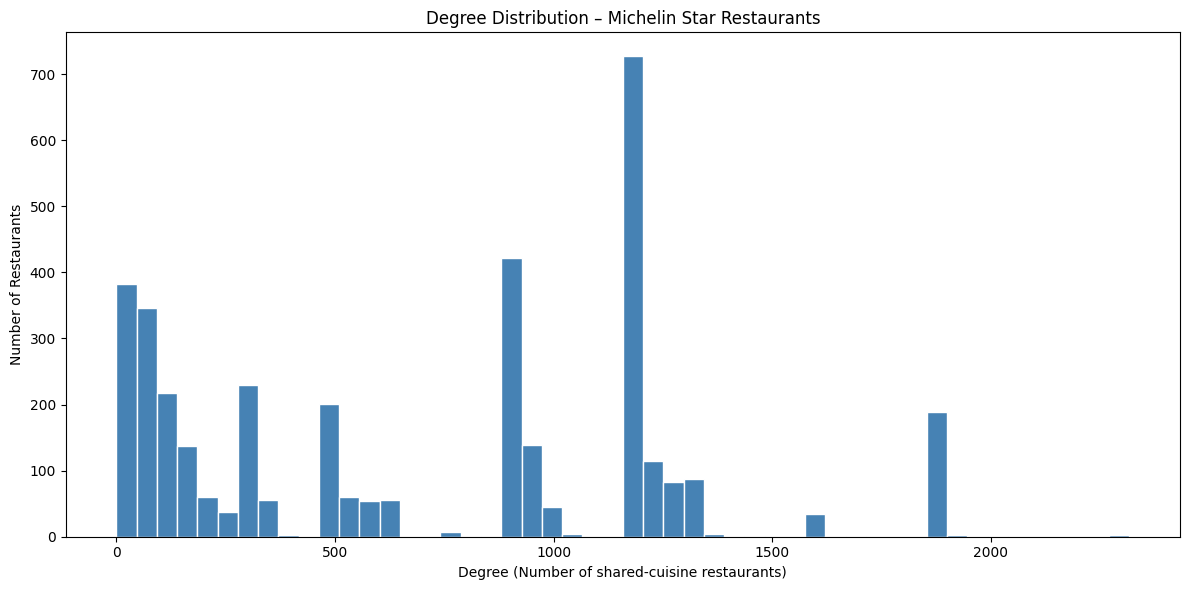

In [25]:
# get the degree of each node in the network
# degree = number of restaurants connected through shared cuisine
degrees = [d for _, d in G.degree()]

# plot the degree distribution
plt.figure(figsize=(12, 6))
plt.hist(degrees, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Degree (Number of shared-cuisine restaurants)')
plt.ylabel('Number of Restaurants')
plt.title('Degree Distribution – Michelin Star Restaurants')
plt.tight_layout()
plt.show()

In [26]:
# Print total number of nodes and edges

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")


Nodes: 3703
Edges: 1289075


In [27]:
# Print how many connected components the network has

print(f"Connected components: {nx.number_connected_components(G)}")

Connected components: 34


In [28]:
# Sort the connected components from largest to smallest
components = sorted(nx.connected_components(G), key=len, reverse=True)

# Print the size of each connected component
for i, c in enumerate(components):
    print(f"Component {i+1}: {len(c)} nodes")

Component 1: 3511 nodes
Component 2: 90 nodes
Component 3: 11 nodes
Component 4: 7 nodes
Component 5: 7 nodes
Component 6: 7 nodes
Component 7: 7 nodes
Component 8: 6 nodes
Component 9: 6 nodes
Component 10: 6 nodes
Component 11: 4 nodes
Component 12: 4 nodes
Component 13: 3 nodes
Component 14: 3 nodes
Component 15: 3 nodes
Component 16: 3 nodes
Component 17: 2 nodes
Component 18: 2 nodes
Component 19: 2 nodes
Component 20: 2 nodes
Component 21: 2 nodes
Component 22: 2 nodes
Component 23: 2 nodes
Component 24: 1 nodes
Component 25: 1 nodes
Component 26: 1 nodes
Component 27: 1 nodes
Component 28: 1 nodes
Component 29: 1 nodes
Component 30: 1 nodes
Component 31: 1 nodes
Component 32: 1 nodes
Component 33: 1 nodes
Component 34: 1 nodes


The average clustering coefficient of the real network is 0.9020838490175493


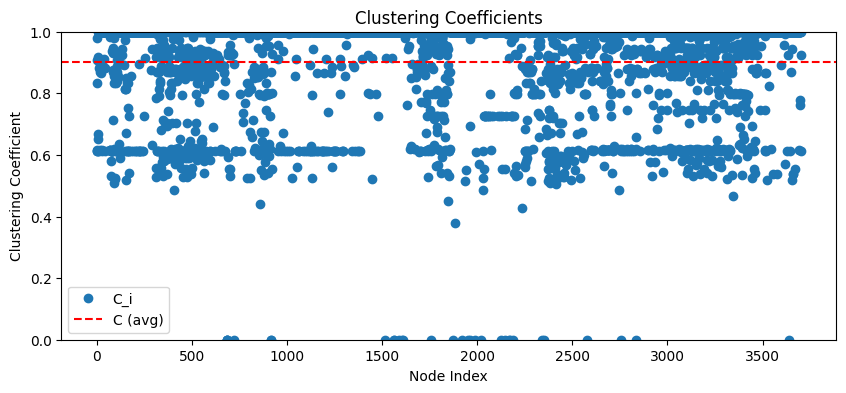

In [29]:
# Compute clustering coefficient for each node only once
clustering_dict = nx.clustering(G)

# Average clustering coefficient
C = sum(clustering_dict.values()) / len(clustering_dict)
print("The average clustering coefficient of the real network is", C)

# List of clustering values
Y = list(clustering_dict.values())

# plot both degree distributions on the same histogram
plt.figure(figsize=(10, 4))
plt.plot(Y, "o", label="C_i")
plt.axhline(y=C, color="r", linestyle="--", label="C (avg)")
plt.ylim(0, 1)
plt.xlabel("Node Index")
plt.ylabel("Clustering Coefficient")
plt.title("Clustering Coefficients")
plt.legend()
plt.show()

In [30]:
# Use the giant component
# since average path length can only be computed on a connected graph
giant = G.subgraph(max(nx.connected_components(G), key=len)).copy()

# compute the exact average shortest path length of the giant component
avg_path_length = nx.average_shortest_path_length(giant)
print(f"Average Path Length: {avg_path_length:.4f}")

Average Path Length: 1.9304


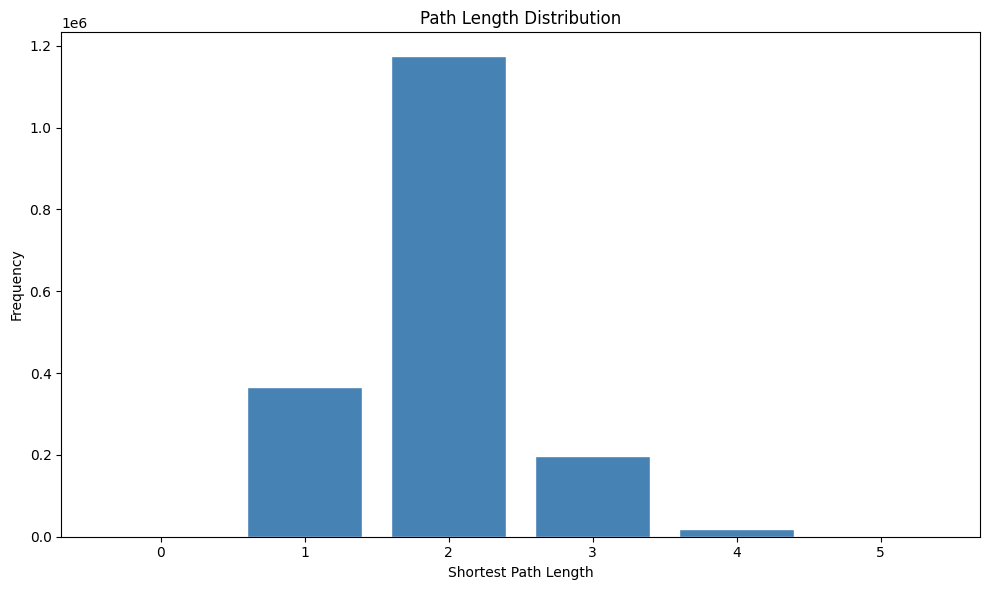

Average Path Length: 1.9304
Standard Deviation: 0.5998


In [31]:
# Randomly sample 500 nodes from the giant component
sample_nodes = random.sample(list(giant.nodes()), 500)
path_lengths = []

# For each sampled node, compute shortest path length
# from that node to all other reachable nodes
for node in sample_nodes:
    lengths = nx.single_source_shortest_path_length(giant, node)
    path_lengths.extend(lengths.values())

# Count how often each path length appears
length_counts = Counter(path_lengths)
x = sorted(length_counts.keys())
y = [length_counts[k] for k in x]

# Plot the sampled path length distribution
plt.figure(figsize=(10, 6))
plt.bar(x, y, color='steelblue', edgecolor='white')
plt.xlabel('Shortest Path Length')
plt.ylabel('Frequency')
plt.title('Path Length Distribution')
plt.tight_layout()
plt.show()

# Print the exact average path length
# and the standard deviation from the sampled path lengths
print(f"Average Path Length: {avg_path_length:.4f}")
print(f"Standard Deviation: {np.std(path_lengths):.4f}")

In [ ]:
# Get the number of nodes and edges in the real network
N = G.number_of_nodes()
E = G.number_of_edges()

# Compute the ER edge probability p
p = (2 * E) / (N * (N - 1))
print("p =", p)

p = 0.18806936364910953


In [32]:
# Generate a small ensemble of ER random graphs
num_graphs = 3

# Store clustering coefficient and path length values
clustering_vals = []
path_lengths = []

for i in range(num_graphs):
    # create an ER random graph with N nodes and edge probability p
    G_rand = nx.erdos_renyi_graph(N, p)

    # find the largest connected component
    if nx.is_connected(G_rand):
        giant_rand = G_rand
    else:
        giant_rand = G_rand.subgraph(max(nx.connected_components(G_rand), key=len)).copy()

    # compute clustering coefficient for the random graph
    C_rand = nx.average_clustering(G_rand)
    clustering_vals.append(C_rand)

    # compute average path length for the largest connected component
    L_rand = nx.average_shortest_path_length(giant_rand)
    path_lengths.append(L_rand)

# print the average clustering coefficient and average path length
# across the random graphs
print("Random Clustering (avg):", np.mean(clustering_vals))
print("Random Path Length (avg):", np.mean(path_lengths))

Random Clustering (avg): 0.1880671142609954
Random Path Length (avg): 1.8119187216073485


In [33]:
# compute the mean and standard deviation
# of clustering coefficient and path length across the ER graphs
print("Random Clustering Mean:", np.mean(clustering_vals))
print("Random Clustering Std:", np.std(clustering_vals))

print("Random Path Length Mean:", np.mean(path_lengths))
print("Random Path Length Std:", np.std(path_lengths))

Random Clustering Mean: 0.1880671142609954
Random Clustering Std: 0.00011290577883322878
Random Path Length Mean: 1.8119187216073485
Random Path Length Std: 0.00010560288079879308


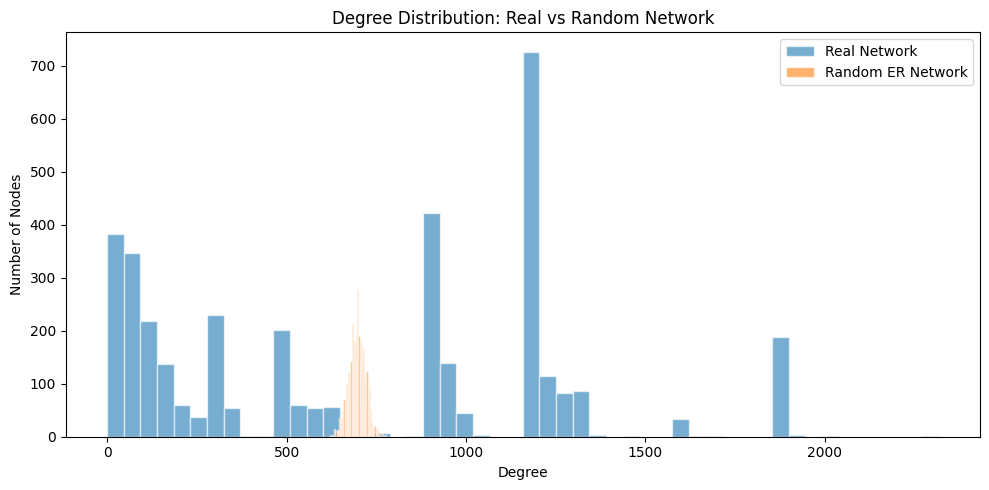

In [34]:
# generate one ER random graph for degree distribution comparison
G_rand = nx.erdos_renyi_graph(N, p)

# get the degree values from the real and random networks
real_degrees = [d for _, d in G.degree()]
rand_degrees = [d for _, d in G_rand.degree()]

# plot both degree distributions on the same histogram
plt.figure(figsize=(10, 5))
plt.hist(real_degrees, bins=50, alpha=0.6, label='Real Network', edgecolor='white')
plt.hist(rand_degrees, bins=50, alpha=0.6, label='Random ER Network', edgecolor='white')
plt.xlabel('Degree')
plt.ylabel('Number of Nodes')
plt.title('Degree Distribution: Real vs Random Network')
plt.legend()
plt.tight_layout()
plt.show()

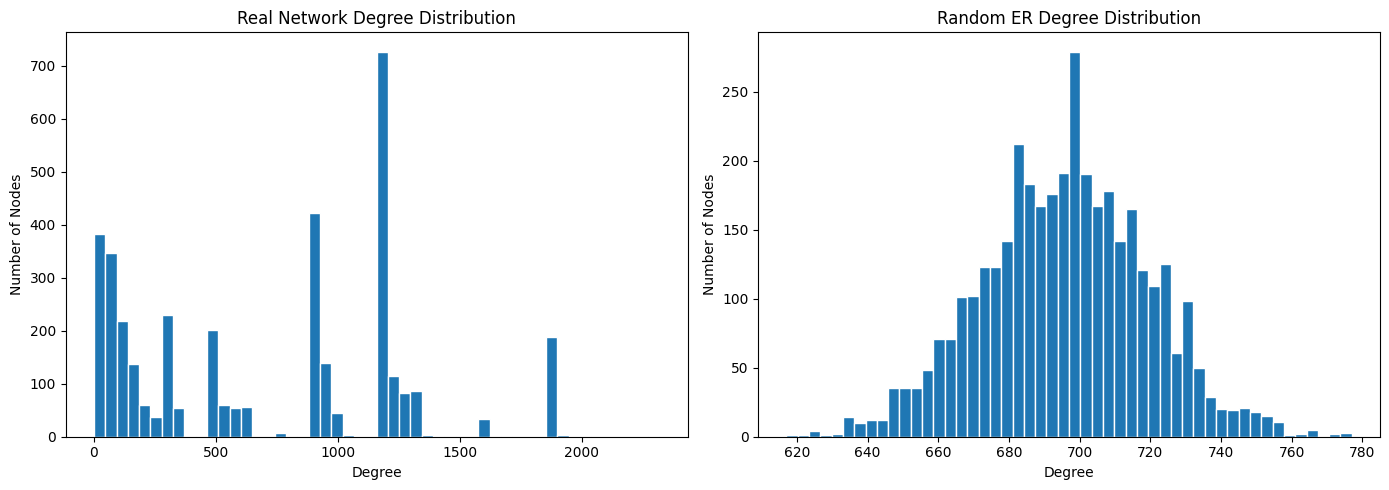

In [35]:
# create two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot the degree distribution of the real network
axes[0].hist(real_degrees, bins=50, edgecolor='white')
axes[0].set_title('Real Network Degree Distribution')
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Number of Nodes')

# plot the degree distribution of the random ER network
axes[1].hist(rand_degrees, bins=50, edgecolor='white')
axes[1].set_title('Random ER Degree Distribution')
axes[1].set_xlabel('Degree')
axes[1].set_ylabel('Number of Nodes')

plt.tight_layout()
plt.show()

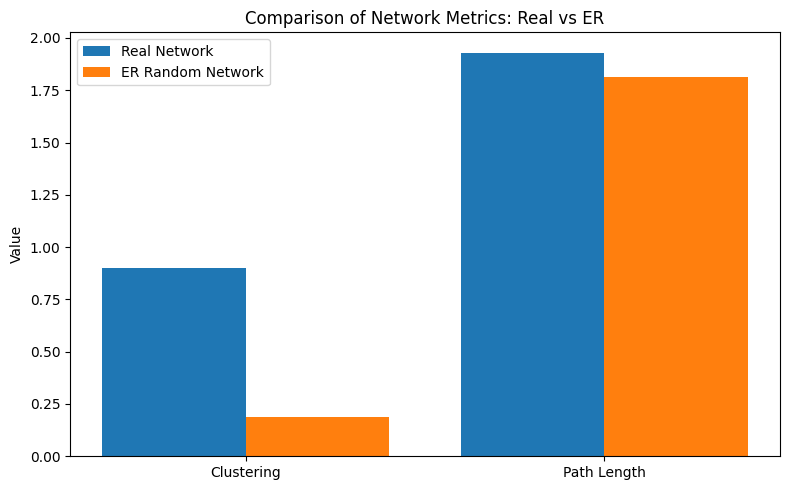

In [36]:
# store the metric names and their values
metrics = ['Clustering', 'Path Length']
real_vals = [0.9021, 1.9304]
rand_vals = [0.1881, 1.8119]

x = range(len(metrics))

# create a bar chart to compare the real and random networks
plt.figure(figsize=(8, 5))
plt.bar(x, real_vals, width=0.4, label='Real Network')
plt.bar([i + 0.4 for i in x], rand_vals, width=0.4, label='ER Random Network')

plt.xticks([i + 0.2 for i in x], metrics)
plt.ylabel('Value')
plt.title('Comparison of Network Metrics: Real vs ER')
plt.legend()
plt.tight_layout()
plt.show()